In [ ]:
from cnn_connectome.datasets.make_movie_from_pano import GetNaturalMovies
from cnn_connectome.utils.plotting import use_static_flyvis_colorbar
from flyvis.analysis import animations
import numpy as np
from pathlib import Path
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import Video, display
from math import ceil
sns.set_context("poster")
plt.rcParams["figure.dpi"] = 100

In [ ]:
data_path = Path("/home/guardomayas/NUIN/pano_scenes/")
PPD = 360/(927) #Imgs width #Pano scenes (251, 927)
ommSizePix = int(np.ceil(5/PPD))  #Equivalent to kernel size in Conv2d
print("Pixel size (deg):", f"{PPD:.3f}")
print("Omm size (pixels):", ommSizePix, '\n')

print("Full eye image requirements:")
print(30*ommSizePix+1, "x", 30*ommSizePix+1, "Px" )


Pixel size (deg): 0.388
Omm size (pixels): 13 

Full eye image requirements:
391 x 391 Px


In [ ]:
dataset = GetNaturalMovies(data_path=data_path)


[Vel] vel_traces: (5, 2, 181)
[Vel] positions:  (5, 2, 181)
[Phase] Phase indices: (5, 3, 927)
[Movies] Total movies: 30
[Render] all_movies: (30, 181, 251, 250)


In [ ]:
sequences = dataset.all_movies
vel_traces = dataset.vel_traces

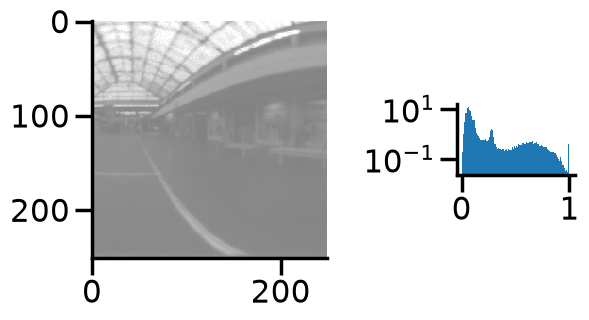

In [ ]:
first_frame  = sequences[0,0,:,:]
v = np.percentile(np.abs(first_frame), 99)
fig, axes = plt.subplots(1, 2, width_ratios=(2, 1))

axes[0].imshow(first_frame, cmap="gray", vmin=-v, vmax=v)
axes[1].hist(first_frame.ravel(), bins=100, density=True)
axes[1].set_yscale('log')
axes[1].set_box_aspect(0.6)  # smaller value makes it shorter

fig.tight_layout()
plt.show()

In [ ]:
def sample_animation(dataset, idx=0, mode='log', lo=1, hi=99.5, viz_fps=None, title=None, save_path=None):
    """
    Animate one sample from GetNaturalMovies.

    Parameters
    ----------
    dataset : GetNaturalMovies
    idx : int
        Movie index (into dataset.all_movies / dataset.movies)
    mode : {'log', 'linear'}
        'log' displays log10(luminance), contrast-stretched between the
        `lo`/`hi` percentiles. 'linear' displays raw luminance the same way.
    lo, hi : float
        Percentiles (0-100) used to set vmin/vmax for display contrast.
    viz_fps : int or None
        Playback frame rate for the animation
    title : str or None
        Custom title
    save_path : str or None
        If given, save animation to mp4/gif

    Returns
    -------
    anim : matplotlib.animation.FuncAnimation
    """

    movie = dataset.all_movies[idx]  # (T, H, W)

    # dataset.vel_traces is indexed by (img_idx, trace_idx), not by movie
    # idx directly -- movie idx also encodes a phase, so we have to look up
    # which (img_idx, trace_idx) this movie corresponds to.
    img_idx, trace_idx, phase_idx = dataset.movies[idx]
    vel = dataset.vel_traces[img_idx, trace_idx]  # (T,)

    # handle movie format
    if movie.ndim == 4:
        # (T, 1, H, W) -> (H, W, T)
        movie_hw_t = np.moveaxis(movie[:, 0, :, :], 0, 2)
    elif movie.ndim == 3:
        # (T, H, W) -> (H, W, T)
        movie_hw_t = np.moveaxis(movie, 0, 2)
    else:
        raise ValueError(f"Unexpected movie shape: {movie.shape}")

    H, W, T = movie_hw_t.shape
    t = np.arange(T) / dataset.sampleFreq

    # dataset.W is the width of the full (unrendered) equirectangular pano,
    # which spans a full 360 deg in azimuth -- gives deg/pixel. Elevation
    # (the H axis) is never resampled from that same pano, so it shares the
    # same deg/pixel scale.
    deg_per_pix = 360.0 / dataset.W
    az_extent = (W / 2) * deg_per_pix
    el_extent = (H / 2) * deg_per_pix


    fig = plt.figure(figsize=(9, 5))
    gs = fig.add_gridspec(1, 2, width_ratios=[2, 1.4])

    ax_img = fig.add_subplot(gs[0])   # spans both rows
    ax_vel = fig.add_subplot(gs[1])   # bottom-right

    positive = movie_hw_t[movie_hw_t > 0]
    floor = np.percentile(positive, 0.1) if positive.size else 1e-8

    if mode == "log":
        y = np.log10(np.maximum(movie_hw_t, floor))
    else:
        y = movie_hw_t

    vmin, vmax = np.percentile(y, [lo, hi])
    im = ax_img.imshow(
        y[:, :, 0], cmap="gray", vmin=vmin, vmax=vmax,
        extent=[-az_extent, az_extent, -el_extent, el_extent],
    )
    ax_img.set_title(f"frame 1/{T}")
    ax_img.set_xlabel("Azimuth (deg)")
    ax_img.set_ylabel("Elevation (deg)")
    if title is not None:
        fig.suptitle(title)


    ax_vel.plot(t, vel, label="v")
    vel_cursor = ax_vel.axvline(t[0], color="k", linestyle="--", alpha=0.7)
    ax_vel.set_title("Velocity trace")
    ax_vel.set_xlabel("time (s)")
    ax_vel.set_ylabel("velocity (deg/s)")
    # ax_vel.grid(True, alpha=0.3)
    ax_vel.legend()

    plt.tight_layout()
    
    def update(frame):
        im.set_data(y[:, :, frame])
        ax_img.set_title(f"frame {frame + 1}/{T}")
        vel_cursor.set_xdata([t[frame], t[frame]])
        return im, vel_cursor

    anim = FuncAnimation(fig, update, frames=T, interval=1000 / viz_fps, blit=False)

    if save_path is not None:
        print(f"Saving animation to {save_path}...")
        anim.save(save_path, fps=viz_fps, dpi=150)

    plt.close(fig)  # close the figure to avoid displaying static version in notebooks
    return anim

# mp4 via ffmpeg: a real video codec exploits frame-to-frame redundancy, so
# this is orders of magnitude smaller than embedding each frame as its own
# base64 PNG (as anim.to_jshtml() does).
movies_dir = Path("_movies")
movies_dir.mkdir(exist_ok=True)
save_path = movies_dir / "sample_0.mp4"

anim = sample_animation(dataset, 0, viz_fps=20, save_path=save_path)
display(Video(save_path, embed=True))